C:\Users\Admin\anaconda3\Lib\site-packages\pyogrio\geopandas.py:346: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["geometry"] = shapely.from_wkb(wkb_values, on_invalid=on_invalid)


 summary:
count    28470.00
mean         2.04
std          1.92
min          0.10
25%          1.10
50%          1.60
75%          2.40
max         75.60
Name: u_ppm, dtype: float64
 Median 1.60
Skewness 11.52
4.7
Hotspot threshold (95th percentile): 4.70 ppm
Number of hotspot samples: 1427


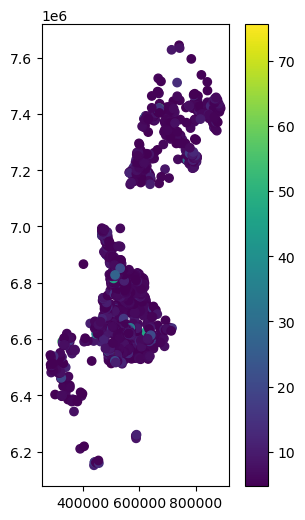

In [2]:
import geopandas as gpd

# Read raw data (_icpms) and save cleaned data
gpd.options.io_engine = "pyogrio" #by default it will be applied to read_file
markgeokemi_icpms = gpd.read_file(
    "C:/Projects/markgeokemi/raw_data/markgeokemi_regional.gpkg",
    layer = "moran_0063mm_hno3_icpms",
    use_arrow = True
).dropna(subset=["unikt_id", "ns", "ew", "geometry"]
).set_crs("EPSG:3006", allow_override=True) #remove NaN
markgeokemi_icpms_clean = markgeokemi_icpms.copy()
markgeokemi_icpms.to_file(
     "C:/Projects/markgeokemi/cleaned_data/markgeokemi_icpms_clean.gpkg",
    driver= "GPKG",
    use_arrow = True) #save in cleaned raw_data

#as_icpms = markgeokemi_icpms_clean["as_ppm"]
as_icpms = markgeokemi_icpms_clean[
    markgeokemi_icpms_clean["as_ppm"] > 0
][["unikt_id", "ns", "ew", "as_ppm", "geometry"]] #filter rows based on a condition that values in column as_ppm >0

#summary stats

as_icpms_stat = as_icpms["as_ppm"].describe()
median_as_icpms = as_icpms["as_ppm"].median()
skew_as_icpms = as_icpms["as_ppm"].skew()

print(f" summary:")
print(as_icpms_stat.round(2))
print(f" Median {median_as_icpms:.2f}")
print(f"Skewness {skew_as_icpms:.2f}")

#print(as_icpms.describe())
thresh_95 = as_icpms["as_ppm"].quantile(0.95)
print(thresh_95)
as_icpms_hotspots = as_icpms[
    as_icpms["as_ppm"] >= thresh_95
]

print(f"Hotspot threshold (95th percentile): {thresh_95:.2f} ppm")
print(f"Number of hotspot samples: {len(as_icpms_hotspots)}")

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(4,6))
as_icpms_hotspots.plot(column="as_ppm", legend=True, ax=ax)

plt.savefig(
    "C:/Projects/markgeokemi/results/as_icpms_hotspots_map.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

as_icpms_hotspots.columns
#plt.figure(figsize= (4,4))
#plt.scatter(markgeokemi_icpms_clean["as_ppm"] , markgeokemi_icpms_clean["fe_ppm"])
#plt.title("data", fontsize= 12)
#plt.xlabel("fe", fontsize= 12)
#plt.ylabel("as", fontsize =12)

